## Import och Databehandling för nederbörsdata från SMHI
*E. Haaf (Chalmers), 2026*

Detta skript läser nederbördsdata direkt från SMHI's CSV-format (nedladdad från https://www.smhi.se/data/hitta-data-for-en-plats/ladda-ner-vaderobservationer/precipitation24HourSum). Skriptet:

1. Tolkar SMHI's CSV-format med metadata-rader i början och extraherar relevant data
2. Tillämpar kvalitetskontroll: ersätter värden med NaN om Kvalitet ≠ "G" (Godkänd)
3. Exporterar till en renare CSV-fil (precip_data.csv) i samma mapp som inmatningsfilen
4. Visualisering

### 0. Importera bibliotek

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

### 1. Tolka SMHI's csv format

In [2]:

# Läs nederbörsdata från SMHI CSV-format

# Ange filsökvägen till SMHI CSV-filen
file_path = "../data/smhi-opendata_5_86420.csv"  # Ange filsökvägen

# Hitta raden med kolumnnamn (börjar med "Från Datum Tid")
# SMHI-filen innehåller metadatablock i början före själva datatabellen
skip_rows = 0
with open(file_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if 'Från Datum Tid' in line:  # Hitta header-raden
            skip_rows = i
            break

# Läs CSV-filen och hoppa över metadata-raderna
df = pd.read_csv(file_path, skiprows=skip_rows, sep=';')  # Läs CSV med tabulatorer som separator

# Välja relevanta kolumner från SMHI-filen
df = df[['Representativt dygn', 'Nederbördsmängd', 'Kvalitet']].copy()  # Välj de kolumner vi behöver

### 2. Kvalitetskontroll

In [3]:
# Tillämpa kvalitetskontroll: ersätt värden med NaN där Kvalitet inte är "G" (Godkänd)
df.loc[df['Kvalitet'] != 'G', 'Nederbördsmängd'] = float('nan')  # NaN för data som inte är godkänd

# Radera Kvalitet-kolumnen (redan använd för filtrering)
df = df.drop('Kvalitet', axis=1)  # Ta bort den tillfälliga kolumnen


### 3. Formatering och export

In [4]:

# Byt namn på kolumner till förenklat format
df.columns = ['Datum', 'Prec']  # Datum: representativt dygn, Prec: nederbördsmängd i mm

# Konvertera Datum till datetime-format
df['Datum'] = pd.to_datetime(df['Datum'])  # Konvertera tidssträngar till datetime
df = df.set_index('Datum').sort_index()

# Säkerställ komplett dagligt tidsindex utan luckor
full_idx = pd.date_range(df.index.min(), df.index.max(), freq='D')
df = df.reindex(full_idx)
df.index.name = 'Datum'

# Nederbördsluckor lämnas som NaN (ingen mätning = okänd, inte noll)
print(f"Totalt antal dagar: {len(df)}")
print(f"Dagar med saknade värden: {df['Prec'].isna().sum()}")
print(f"Inferred freq: {pd.infer_freq(df.index)}")  # bör vara 'D'

# Spara som CSV i samma mapp som inmatningsfilen
output_directory = os.path.dirname(file_path)  # Använd samma katalog som inmatningsfilen
output_path = os.path.join(output_directory, 'precip_data_km.csv')  # Skapa sökväg till utdatafilen

df.to_csv(output_path, index=True)  # Exportera till CSV

print(f"Behandlad nederbörsdata har sparats till {output_path}")  # Bekräfta att filen sparades
print(df.head())

Totalt antal dagar: 10945
Dagar med saknade värden: 25
Inferred freq: D
Behandlad nederbörsdata har sparats till ../data\precip_data_km.csv
            Prec
Datum           
1995-12-14   0.0
1995-12-15   0.0
1995-12-16   0.0
1995-12-17   0.2
1995-12-18   0.0


### 4. Visualisering

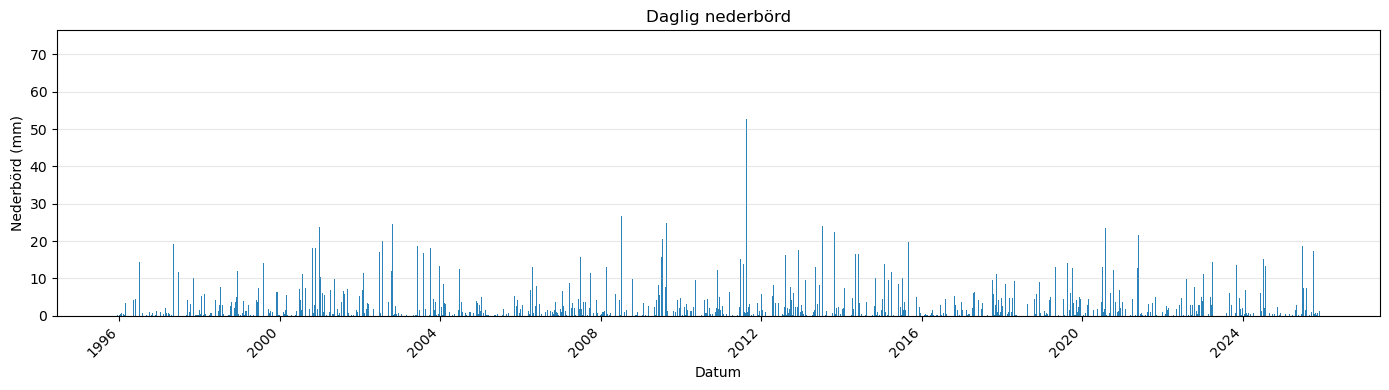

In [ ]:
# Skapa ett stapeldiagram av den slutliga nederbördsserien
fig, ax = plt.subplots(figsize=(14, 4))

# Visa daglig nederbörd som staplar
ax.bar(df.index, df['Prec'], width=1.0, color='#2b83ba')

# Lägg till rubrik och axel-etiketter
ax.set_title('Daglig nederbörd')
ax.set_xlabel('Datum')
ax.set_ylabel('Nederbörd (mm)')

# Förbättra läsbarheten i figuren
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Visa figuren utan att blockera kerneln
plt.show(block=False)
plt.close(fig)